In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install groq

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle, time, os, json
from dotenv import load_dotenv

import mlflow
import mlflow.sklearn
import dagshub

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

load_dotenv()
pd.set_option('display.max_columns', None)

# Configurar MLflow con DagsHub ESTO ES LO NUEVO DEL PROYECTO 2
dagshub.init(
    repo_owner=os.getenv("DAGSHUB_USER"),
    repo_name="churn-prediction-llm",
    mlflow=True
)

mlflow.set_experiment("churn-prediction-telco")

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print("Configuración completada ✓")

C:\Users\cardo\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accessing as EduardoCardoza

Initialized MLflow to track repo "EduardoCardoza/churn-prediction-llm"

Repository EduardoCardoza/churn-prediction-llm initialized!

MLflow Tracking URI: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow
Configuración completada ✓


In [2]:
train_df = pd.read_parquet('../data/processed/train.parquet')
test_df  = pd.read_parquet('../data/processed/test.parquet')

X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']
X_test  = test_df.drop('Churn', axis=1)
y_test  = test_df['Churn']

#ESTO ES LO NUEVO, abre el contenido del artefacto resumen y lo pone en la variable resumen_prep
with open('../artifacts/resumen_preprocesamiento.json') as f:
    resumen_prep = json.load(f)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (5634, 30) | Test: (1409, 30)


In [3]:
def calcular_metricas(model, X_test, y_test):
    """Calcula y retorna métricas de clasificación binaria."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "recall"   : round(recall_score(y_test, y_pred), 4),
        "f1"       : round(f1_score(y_test, y_pred), 4),
        "roc_auc"  : round(roc_auc_score(y_test, y_proba), 4),
    }

In [4]:
with mlflow.start_run(run_name="logistic_regression_baseline"):

    # Parámetros
    params = {"C": 1.0, "max_iter": 1000, "class_weight": None}
    mlflow.log_params(params)

    # Datos del preprocesamiento
    mlflow.log_params({
        "train_size"      : resumen_prep["registros_train"],
        "test_size"       : resumen_prep["registros_test"],
        "n_features"      : resumen_prep["total_features_encoded"],
        "churn_rate_train": resumen_prep["proporcion_churn_train"],
    })

    # Entrenar
    lr = LogisticRegression(**params, random_state=42)
    lr.fit(X_train, y_train)

    # Métricas
    metricas_lr = calcular_metricas(lr, X_test, y_test)
    mlflow.log_metrics(metricas_lr)

    # Latencia online
    start = time.time()
    for i in range(100):
        lr.predict(X_test.iloc[[i]])
    latencia = ((time.time() - start) / 100) * 1000
    mlflow.log_metric("latencia_ms", round(latencia, 2))

    # Guardar modelo como artefacto
    mlflow.sklearn.log_model(lr, "logistic_regression_model")

    print(f"Regresión Logística → F1: {metricas_lr['f1']} | ROC-AUC: {metricas_lr['roc_auc']}")
    print(f"Latencia: {round(latencia,2)} ms | Run ID: {mlflow.active_run().info.run_id}")

2026/09/01 15:36:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Regresión Logística → F1: 0.6049 | ROC-AUC: 0.8422
Latencia: 2.04 ms | Run ID: 5ab6c02627dd439bb24a66205cdafcfa
🏃 View run logistic_regression_baseline at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0/runs/5ab6c02627dd439bb24a66205cdafcfa
🧪 View experiment at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0


In [5]:
with mlflow.start_run(run_name="random_forest_baseline"):

    params = {
        "n_estimators" : 100,
        "max_depth"    : 10,
        "random_state" : 42,
        "class_weight" : None
    }
    mlflow.log_params(params)
    mlflow.log_params({
        "train_size"      : resumen_prep["registros_train"],
        "n_features"      : resumen_prep["total_features_encoded"],
        "churn_rate_train": resumen_prep["proporcion_churn_train"],
    })

    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)

    metricas_rf = calcular_metricas(rf, X_test, y_test)
    mlflow.log_metrics(metricas_rf)

    start = time.time()
    for i in range(100):
        rf.predict(X_test.iloc[[i]])
    latencia = ((time.time() - start) / 100) * 1000
    mlflow.log_metric("latencia_ms", round(latencia, 2))

    mlflow.sklearn.log_model(rf, "random_forest_model")

    print(f"Random Forest → F1: {metricas_rf['f1']} | ROC-AUC: {metricas_rf['roc_auc']}")
    print(f"Latencia: {round(latencia,2)} ms | Run ID: {mlflow.active_run().info.run_id}")

2026/09/01 15:37:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest → F1: 0.5889 | ROC-AUC: 0.8435
Latencia: 19.0 ms | Run ID: abcd3b0df20248cbbc57098b780c487b
🏃 View run random_forest_baseline at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0/runs/abcd3b0df20248cbbc57098b780c487b
🧪 View experiment at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0


In [6]:
with mlflow.start_run(run_name="random_forest_baseline"):

    params = {
        "n_estimators" : 100,
        "max_depth"    : 10,
        "random_state" : 42,
        "class_weight" : None
    }
    mlflow.log_params(params)
    mlflow.log_params({
        "train_size"      : resumen_prep["registros_train"],
        "n_features"      : resumen_prep["total_features_encoded"],
        "churn_rate_train": resumen_prep["proporcion_churn_train"],
    })

    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)

    metricas_rf = calcular_metricas(rf, X_test, y_test)
    mlflow.log_metrics(metricas_rf)

    start = time.time()
    for i in range(100):
        rf.predict(X_test.iloc[[i]])
    latencia = ((time.time() - start) / 100) * 1000
    mlflow.log_metric("latencia_ms", round(latencia, 2))

    mlflow.sklearn.log_model(rf, "random_forest_model")

    print(f"Random Forest → F1: {metricas_rf['f1']} | ROC-AUC: {metricas_rf['roc_auc']}")
    print(f"Latencia: {round(latencia,2)} ms | Run ID: {mlflow.active_run().info.run_id}")

2026/09/01 15:39:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest → F1: 0.5889 | ROC-AUC: 0.8435
Latencia: 23.08 ms | Run ID: ddc78ae2866b47c2b86554b3de212c19
🏃 View run random_forest_baseline at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0/runs/ddc78ae2866b47c2b86554b3de212c19
🧪 View experiment at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0


In [9]:
with mlflow.start_run(run_name="gradient_boosting_baseline"):

    params = {
        "n_estimators" : 100,
        "max_depth"    : 5,
        "learning_rate": 0.1,
        "random_state" : 42
    }
    mlflow.log_params(params)
    mlflow.log_params({
        "train_size"      : resumen_prep["registros_train"],
        "n_features"      : resumen_prep["total_features_encoded"],
        "churn_rate_train": resumen_prep["proporcion_churn_train"],
    })

    gb = GradientBoostingClassifier(**params)
    gb.fit(X_train, y_train)

    metricas_gb = calcular_metricas(gb, X_test, y_test)
    mlflow.log_metrics(metricas_gb)

    start = time.time()
    for i in range(100):
        gb.predict(X_test.iloc[[i]])
    latencia = ((time.time() - start) / 100) * 1000
    mlflow.log_metric("latencia_ms", round(latencia, 2))

    mlflow.sklearn.log_model(gb, "gradient_boosting_model")

    print(f"Gradient Boosting → F1: {metricas_gb['f1']} | ROC-AUC: {metricas_gb['roc_auc']}")
    print(f"Latencia: {round(latencia,2)} ms | Run ID: {mlflow.active_run().info.run_id}")

2026/09/01 15:47:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Gradient Boosting → F1: 0.5837 | ROC-AUC: 0.8365
Latencia: 2.55 ms | Run ID: 4e21edd4b19d43c681bbee6a85ea67c3
🏃 View run gradient_boosting_baseline at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0/runs/4e21edd4b19d43c681bbee6a85ea67c3
🧪 View experiment at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0


In [10]:
param_dist = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "class_weight"    : ["balanced", None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20, cv=5, scoring="f1",
    random_state=42, n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)

print(f"Mejores parámetros: {rf_search.best_params_}")
print(f"Mejor F1 (CV): {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced'}
Mejor F1 (CV): 0.6302


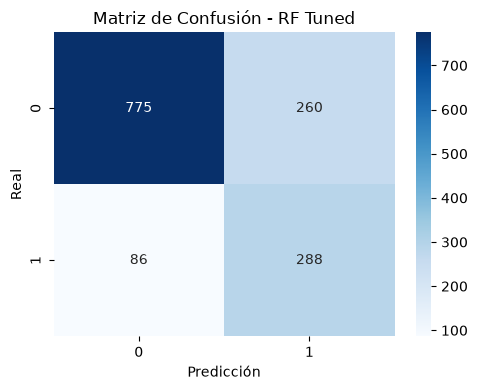

2026/09/01 15:54:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'churn-prediction-rf-prod'.
2026/09/01 15:55:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: churn-prediction-rf-prod, version 1
Created version '1' of model 'churn-prediction-rf-prod'.



MEJOR MODELO REGISTRADO EN MLFLOW
Run ID: 810c9252fe8a437b84acf537ec672004
F1:      0.6247
ROC-AUC: 0.8414
Latencia:22.05 ms
🏃 View run random_forest_tuned_BEST at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0/runs/810c9252fe8a437b84acf537ec672004
🧪 View experiment at: https://dagshub.com/EduardoCardoza/churn-prediction-llm.mlflow/#/experiments/0


In [11]:
best_model = rf_search.best_estimator_

with mlflow.start_run(run_name="random_forest_tuned_BEST") as run:

    # Parámetros del mejor modelo
    mlflow.log_params(rf_search.best_params_)
    mlflow.log_params({
        "tuning_method"   : "RandomizedSearchCV",
        "n_iter"          : 20,
        "cv_folds"        : 5,
        "scoring"         : "f1",
        "train_size"      : resumen_prep["registros_train"],
        "n_features"      : resumen_prep["total_features_encoded"],
        "churn_rate_train": resumen_prep["proporcion_churn_train"],
    })

    # Métricas en test
    metricas_best = calcular_metricas(best_model, X_test, y_test)
    mlflow.log_metrics(metricas_best)

    # Mejor score de CV
    mlflow.log_metric("best_cv_f1", round(rf_search.best_score_, 4))

    # Latencia online
    start = time.time()
    for i in range(100):
        best_model.predict(X_test.iloc[[i]])
    latencia = ((time.time() - start) / 100) * 1000
    throughput = 100 / ((time.time() - start) + 0.0001)
    mlflow.log_metric("latencia_ms", round(latencia, 2))
    mlflow.log_metric("throughput_pred_seg", round(throughput, 1))

    # Matriz de confusión como artefacto
    cm = confusion_matrix(y_test, best_model.predict(X_test))
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title("Matriz de Confusión - RF Tuned")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.savefig("../artifacts/confusion_matrix_best.png")
    mlflow.log_artifact("../artifacts/confusion_matrix_best.png")
    plt.show()

    # Guardar métricas como CSV y subirlas como artefacto
    resultados_todos = pd.DataFrame([
        {"modelo": "Logistic Regression", **metricas_lr},
        {"modelo": "Random Forest",       **metricas_rf},
        {"modelo": "Gradient Boosting",   **metricas_gb},
        {"modelo": "RF Tuned (BEST)",     **metricas_best},
    ])
    resultados_todos.to_csv("../artifacts/resultados_metricas_v2.csv", index=False)
    mlflow.log_artifact("../artifacts/resultados_metricas_v2.csv")

    # Guardar modelo localmente también
    with open("../artifacts/modelo_v2.pkl", "wb") as f:
        pickle.dump(best_model, f)
    mlflow.log_artifact("../artifacts/modelo_v2.pkl")

    # Registrar como modelo productivo en MLflow Model Registry
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="random_forest_tuned",
        registered_model_name="churn-prediction-rf-prod"
    )

    best_run_id = run.info.run_id
    print(f"\n{'='*55}")
    print(f"MEJOR MODELO REGISTRADO EN MLFLOW")
    print(f"{'='*55}")
    print(f"Run ID: {best_run_id}")
    print(f"F1:      {metricas_best['f1']}")
    print(f"ROC-AUC: {metricas_best['roc_auc']}")
    print(f"Latencia:{round(latencia,2)} ms")
    print(f"{'='*55}")

In [12]:
print("Validación cruzada (5-fold) — F1 score:")
modelos_comparar = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
    "RF Tuned (Best)"     : best_model,
}

cv_resultados = []
for nombre, modelo in modelos_comparar.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1')
    cv_resultados.append({
        "modelo": nombre,
        "f1_cv_mean": round(scores.mean(), 4),
        "f1_cv_std" : round(scores.std(), 4)
    })
    print(f"  {nombre}: {scores.mean():.4f} (+/- {scores.std():.4f})")

pd.DataFrame(cv_resultados).to_csv("../artifacts/cv_resultados.csv", index=False)

Validación cruzada (5-fold) — F1 score:
  Logistic Regression: 0.5986 (+/- 0.0280)
  Random Forest: 0.5455 (+/- 0.0222)
  Gradient Boosting: 0.5705 (+/- 0.0280)
  RF Tuned (Best): 0.6302 (+/- 0.0175)


In [13]:
fig = px.bar(
    resultados_todos,
    x="modelo", y="f1",
    color="modelo",
    title="Comparación de modelos — F1 Score en Test Set",
    labels={"f1": "F1 Score", "modelo": "Modelo"},
    text="f1"
)
fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig.update_layout(showlegend=False, yaxis_range=[0, 1])
fig.write_html("../artifacts/comparacion_modelos.html")
fig.show()

print("\nResumen final:")
print(resultados_todos.to_string(index=False))


Resumen final:
             modelo  accuracy  precision  recall     f1  roc_auc
Logistic Regression    0.8062     0.6593  0.5588 0.6049   0.8422
      Random Forest    0.8048     0.6678  0.5267 0.5889   0.8435
  Gradient Boosting    0.7935     0.6277  0.5455 0.5837   0.8365
    RF Tuned (BEST)    0.7544     0.5255  0.7701 0.6247   0.8414


## 🔗 Experimentos en DagsHub (MLflow)

Ver todos los experimentos registrados, métricas, parámetros y artefactos:

👉 https://dagshub.com/TU_USUARIO/churn-prediction-llm/experiments

### Modelo productivo registrado:
- **Nombre**: `churn-prediction-rf-prod`
- **Algoritmo**: Random Forest (tuned con RandomizedSearchCV)
- **Registro**: MLflow Model Registry en DagsHub